In [36]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import plotly.offline as pyo

pyo.init_notebook_mode(connected=True)

In [38]:
df = yf.download(['JAYNECOIND.NS', 'CESC.NS', 'IEX.NS', 'JINDALSAW.NS'], start='2020-01-01', end='2026-01-31')['Close']
df

[*********************100%***********************]  4 of 4 completed


Ticker,CESC.NS,IEX.NS,JAYNECOIND.NS,JINDALSAW.NS
Date,,,,
2020-01-01,55.337612,43.350887,3.200000,38.635761
2020-01-02,55.941521,45.638088,3.500000,38.613071
2020-01-03,54.993050,48.440292,3.550000,39.883537
2020-01-06,53.970474,50.939556,3.450000,37.387981
2020-01-07,53.833389,50.151917,3.750000,38.000523
...,...,...,...,...
2026-01-23,140.429993,126.014915,71.559998,177.720001
2026-01-27,140.440002,126.034683,71.940002,178.190002
2026-01-28,142.949997,127.180901,74.820000,180.910004


In [40]:
df = np.log(df/df.shift(1)).dropna()
df

Ticker,CESC.NS,IEX.NS,JAYNECOIND.NS,JINDALSAW.NS
Date,,,,
2020-01-02,0.010854,0.051415,0.089612,-0.000587
2020-01-03,-0.017100,0.059589,0.014185,0.032373
2020-01-06,-0.018770,0.050308,-0.028573,-0.064614
2020-01-07,-0.002543,-0.015583,0.083382,0.016251
2020-01-08,-0.007807,0.004219,0.000000,0.004171
...,...,...,...,...
2026-01-23,-0.021277,-0.027304,-0.033934,-0.056126
2026-01-27,0.000071,0.000157,0.005296,0.002641
2026-01-28,0.017715,0.009053,0.039253,0.015149


# Portfolio Returns
(weight1 * mean1)+ (weight2 * mean2).......+ (weightN * meanN)

In [43]:
def portfolioreturns(weights):
    return np.dot(df.mean(), weights) * 252

# Portfolio Variance

In [46]:
def portfoliostd(weights):
    return (np.dot(np.dot(df.cov(), weights), weights))**(1/2) * np.sqrt(252)

In [48]:
def weightscreator(df):
    rand = np.random.random(len(df.columns))
    rand /= rand.sum()
    return rand

In [50]:
returns =[]
stds = []
w = []

for i in range(50000):
    weights = weightscreator(df)
    returns.append(portfolioreturns(weights))
    stds.append(portfoliostd(weights))
    w.append(weights)

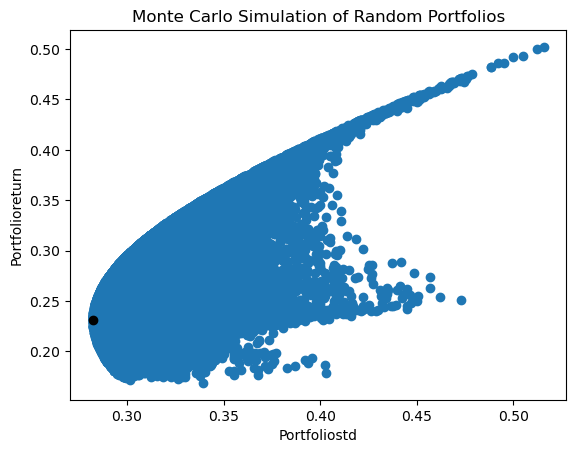

In [60]:
plt.scatter(stds,returns)
plt.scatter(min(stds), returns[stds.index(min(stds))], c='black')
plt.title('Monte Carlo Simulation of Random Portfolios')
plt.xlabel('Portfoliostd')
plt.ylabel('Portfolioreturn')
plt.show()

In [58]:
import plotly.graph_objs as go

In [68]:
returns[stds.index(min(stds))]

0.23100799772716993

In [70]:
stds.index(min(stds))

29130